In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
# ── Cell 1 : imports + load data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr
from scipy import ndimage
from scipy import stats
import subprocess
import glob, os, warnings
warnings.filterwarnings("ignore")

# install mann-kendall
subprocess.run(['pip', 'install', 'pymannkendall', '--quiet'], check=True)
import pymannkendall as mk

# install regionmask
subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

print("imports done ✓")

# ── load ERA5 data ──
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files  = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")

ds = xr.open_mfdataset(nc_files, combine='by_coords',
                        engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat         = ds['latitude'].values.astype('float32')
lon         = ds['longitude'].values.astype('float32')
time        = ds['time'].values
times_pd    = pd.to_datetime(time)

print(f"shape : {data_precip.shape}")
print(f"time  : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}")

imports done ✓
found 46 files
shape : (5612, 141, 161)
time  : 1979-06-01 → 2024-09-30


In [5]:
# ── Cell 2 : India mask + threshold ──────────────────────────────────────────
RAINY_DAY_MIN = 1.0
PERCENTILE    = 99.0
FLOOR_MM      = 50.0

# India mask
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw  = countries.mask(lon, lat)
india_mask = (india_raw.values == 98)
print(f"India cells : {india_mask.sum()} / {141*161}")

# mask — India cells + rainy days only
data_masked = np.where(
    (data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
    data_precip, np.nan
).astype('float32')

# threshold
jjas_mask  = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data  = data_masked[jjas_mask, :, :]
per_grid_99 = np.nanpercentile(jjas_data, PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0

# exceedance mask
data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d     = np.broadcast_to(
    per_grid_threshold[np.newaxis, :, :], data_precip.shape
).copy().astype('float32')
c = (data_precip_safe > threshold_3d)

print(f"exceedance mask shape   : {c.shape}")
print(f"overall exceedance rate : {c.mean()*100:.3f}%")
print("threshold done ✓")

India cells : 4452 / 22701
exceedance mask shape   : (5612, 141, 161)
overall exceedance rate : 0.114%
threshold done ✓


In [6]:
# ── Cell 3 : detection — 4-connectivity AND 8-connectivity ───────────────────
# run both in one loop, store separately

struct4 = ndimage.generate_binary_structure(2, 1)  # 4-connectivity
struct8 = ndimage.generate_binary_structure(2, 2)  # 8-connectivity

n_days = len(time)

# 4-connectivity arrays
NT4    = np.zeros(n_days, dtype='int32')
NE4    = np.zeros(n_days, dtype='int32')
Label4 = np.zeros((n_days, len(lat), len(lon)), dtype='int32')

# 8-connectivity arrays
NT8    = np.zeros(n_days, dtype='int32')
NE8    = np.zeros(n_days, dtype='int32')
Label8 = np.zeros((n_days, len(lat), len(lon)), dtype='int32')

for k in range(n_days):
    img = c[k].astype('int8')
    NT4[k] = NT8[k] = int(img.sum())  # NT same for both

    lab4, nr4 = ndimage.label(img, structure=struct4)
    lab8, nr8 = ndimage.label(img, structure=struct8)

    Label4[k] = lab4
    Label8[k] = lab8
    NE4[k]    = nr4
    NE8[k]    = nr8

    if k % 1000 == 0:
        print(f"  day {k:>5}/{n_days}  |  "
              f"NE4: {nr4}  NE8: {nr8}")

print(f"\ndetection complete ✓")
print(f"mean NE (4-conn) : {NE4.mean():.2f}")
print(f"mean NE (8-conn) : {NE8.mean():.2f}")
print(f"mean NT          : {NT4.mean():.2f}  (same for both)")

  day     0/5612  |  NE4: 0  NE8: 0
  day  1000/5612  |  NE4: 0  NE8: 0
  day  2000/5612  |  NE4: 2  NE8: 2
  day  3000/5612  |  NE4: 2  NE8: 2
  day  4000/5612  |  NE4: 5  NE8: 5
  day  5000/5612  |  NE4: 3  NE8: 3

detection complete ✓
mean NE (4-conn) : 2.65
mean NE (8-conn) : 2.43
mean NT          : 25.93  (same for both)


In [7]:
# ── Cell 4 : size distribution — 4 vs 8 connectivity ────────────────────────
# reference paper equivalent categories at 0.25°:
# small  < 16 cells  (<12,300 km²)  — sub-reference-paper scale
# medium 16-90 cells (12,300-70,000 km²)
# large  ≥91 cells   (≥70,000 km²)

def get_size_distribution(Label_arr, NE_arr, name):
    sub   = 0  # <16 cells
    med   = 0  # 16-90
    large = 0  # ≥91
    total = 0

    for k in range(n_days):
        if NE_arr[k] == 0:
            continue
        labeled = Label_arr[k]
        labels  = np.unique(labeled)
        labels  = labels[labels > 0]
        for lbl in labels:
            size = int((labeled == lbl).sum())
            total += 1
            if size < 16:
                sub   += 1
            elif size <= 90:
                med   += 1
            else:
                large += 1

    print(f"\n{name}:")
    print(f"  total ERE objects     : {total:,}")
    print(f"  sub-ref  (<16 cells)  : {sub:>8,}  ({sub/total*100:.1f}%)")
    print(f"  medium  (16-90 cells) : {med:>8,}  ({med/total*100:.1f}%)")
    print(f"  large   (≥91 cells)   : {large:>8,}  ({large/total*100:.1f}%)")
    return total, sub, med, large

t4, s4, m4, l4 = get_size_distribution(Label4, NE4, "4-connectivity")
t8, s8, m8, l8 = get_size_distribution(Label8, NE8, "8-connectivity")

print(f"\n{'Metric':<30} {'4-conn':>10} {'8-conn':>10} {'change':>10}")
print("-" * 62)
print(f"{'Total EREs':<30} {t4:>10,} {t8:>10,} {t8-t4:>+10,}")
print(f"{'Sub-ref (<16 cells)':<30} {s4:>10,} {s8:>10,} {s8-s4:>+10,}")
print(f"{'Medium (16-90)':<30} {m4:>10,} {m8:>10,} {m8-m4:>+10,}")
print(f"{'Large (≥91)':<30} {l4:>10,} {l8:>10,} {l8-l4:>+10,}")


4-connectivity:
  total ERE objects     : 14,864
  sub-ref  (<16 cells)  :   12,380  (83.3%)
  medium  (16-90 cells) :    2,345  (15.8%)
  large   (≥91 cells)   :      139  (0.9%)

8-connectivity:
  total ERE objects     : 13,659
  sub-ref  (<16 cells)  :   11,135  (81.5%)
  medium  (16-90 cells) :    2,381  (17.4%)
  large   (≥91 cells)   :      143  (1.0%)

Metric                             4-conn     8-conn     change
--------------------------------------------------------------
Total EREs                         14,864     13,659     -1,205
Sub-ref (<16 cells)                12,380     11,135     -1,245
Medium (16-90)                      2,345      2,381        +36
Large (≥91)                           139        143         +4


In [9]:
# ── Cell 5 : apply minimum size filter (≥16 cells) ───────────────────────────
# Removes all ERE objects below the reference paper's effective detection
# threshold (~12,300 km²). Makes ERA5 analysis directly comparable to IMD paper.
# Run for BOTH 4-conn and 8-conn so all 4 configs are covered.

MIN_SIZE = 16  # cells — equivalent to ~12,300 km² at 0.25°

def apply_size_filter(Label_arr, NE_arr, min_size, name):
    """
    Returns filtered NT, NE arrays and a new Label array with
    sub-threshold objects zeroed out.
    """
    n_days = Label_arr.shape[0]
    NT_filt = np.zeros(n_days, dtype='int32')
    NE_filt = np.zeros(n_days, dtype='int32')
    Label_filt = np.zeros_like(Label_arr)

    for k in range(n_days):
        labeled = Label_arr[k]
        if NE_arr[k] == 0:
            continue

        new_label = np.zeros_like(labeled)
        new_id    = 0

        for lbl in range(1, NE_arr[k] + 1):
            mask = (labeled == lbl)
            size = int(mask.sum())
            if size >= min_size:
                new_id += 1
                new_label[mask] = new_id

        Label_filt[k] = new_label
        NE_filt[k]    = new_id
        NT_filt[k]    = int((new_label > 0).sum())

        if k % 1000 == 0:
            print(f"  [{name}] day {k:>5}/{n_days}  NE_filt: {new_id}")

    print(f"\n[{name}] filter complete ✓")
    print(f"  mean NE (all sizes) : {NE_arr.mean():.3f}/day")
    print(f"  mean NE (≥16 cells) : {NE_filt.mean():.3f}/day")
    print(f"  mean NT (all sizes) : {NT_arr_ref:.2f}/day")
    print(f"  mean NT (≥16 cells) : {NT_filt.mean():.2f}/day")
    return NT_filt, NE_filt, Label_filt

NT_arr_ref = NT4.mean()   # NT is the same for both conn types

NT4_filt, NE4_filt, Label4_filt = apply_size_filter(Label4, NE4, MIN_SIZE, "4-conn")
NT8_filt, NE8_filt, Label8_filt = apply_size_filter(Label8, NE8, MIN_SIZE, "8-conn")

  [4-conn] day  2000/5612  NE_filt: 1
  [4-conn] day  3000/5612  NE_filt: 0
  [4-conn] day  4000/5612  NE_filt: 2
  [4-conn] day  5000/5612  NE_filt: 1

[4-conn] filter complete ✓
  mean NE (all sizes) : 2.649/day
  mean NE (≥16 cells) : 0.443/day
  mean NT (all sizes) : 25.93/day
  mean NT (≥16 cells) : 16.72/day
  [8-conn] day  2000/5612  NE_filt: 1
  [8-conn] day  3000/5612  NE_filt: 0
  [8-conn] day  4000/5612  NE_filt: 2
  [8-conn] day  5000/5612  NE_filt: 1

[8-conn] filter complete ✓
  mean NE (all sizes) : 2.434/day
  mean NE (≥16 cells) : 0.450/day
  mean NT (all sizes) : 25.93/day
  mean NT (≥16 cells) : 17.11/day


In [10]:
# ── Cell 6 : annual time series — all 4 configs ───────────────────────────────
# Computes annual NT, NE, S-bar for Central India (15-25N, 75-85E)
# for all four configs: 4-conn/all, 8-conn/all, 4-conn/≥16, 8-conn/≥16

CI_LAT = (15, 25)
CI_LON = (75, 85)

lat_idx = np.where((lat >= CI_LAT[0]) & (lat <= CI_LAT[1]))[0]
lon_idx = np.where((lon >= CI_LON[0]) & (lon <= CI_LON[1]))[0]

years = np.arange(1979, 2025)

def annual_series(Label_arr, NT_arr, NE_arr, times_pd, lat_idx, lon_idx, name):
    """
    ERE belongs to CI if at least one cell is within the CI box.
    Returns DataFrame with columns: year, NT, NE, Sbar
    """
    rows = []
    for yr in years:
        yr_mask = (times_pd.year == yr)
        yr_idx  = np.where(yr_mask)[0]

        NT_yr = 0
        NE_yr = 0

        for k in yr_idx:
            labeled = Label_arr[k]
            if labeled.max() == 0:
                continue

            # CI sub-array
            ci_labeled = labeled[np.ix_(lat_idx, lon_idx)]
            ci_labels  = np.unique(ci_labeled)
            ci_labels  = ci_labels[ci_labels > 0]

            NE_yr += len(ci_labels)

            # NT = total cells of those EREs over full India domain
            for lbl in ci_labels:
                NT_yr += int((labeled == lbl).sum())

        sbar = NT_yr / NE_yr if NE_yr > 0 else np.nan
        rows.append({'year': yr, 'NT': NT_yr, 'NE': NE_yr, 'Sbar': sbar})

    df = pd.DataFrame(rows)
    print(f"\n[{name}] annual series summary:")
    print(f"  NT  — mean: {df.NT.mean():.1f}  std: {df.NT.std():.1f}")
    print(f"  NE  — mean: {df.NE.mean():.1f}  std: {df.NE.std():.1f}")
    print(f"  Sbar— mean: {df.Sbar.mean():.2f}  std: {df.Sbar.std():.2f}")
    return df

df_4all  = annual_series(Label4,      NT4,      NE4,      times_pd, lat_idx, lon_idx, "4-conn / all sizes")
df_8all  = annual_series(Label8,      NT8,      NE8,      times_pd, lat_idx, lon_idx, "8-conn / all sizes")
df_4filt = annual_series(Label4_filt, NT4_filt, NE4_filt, times_pd, lat_idx, lon_idx, "4-conn / ≥16 cells")
df_8filt = annual_series(Label8_filt, NT8_filt, NE8_filt, times_pd, lat_idx, lon_idx, "8-conn / ≥16 cells")


[4-conn / all sizes] annual series summary:
  NT  — mean: 1478.7  std: 485.0
  NE  — mean: 91.9  std: 22.6
  Sbar— mean: 16.17  std: 3.90

[8-conn / all sizes] annual series summary:
  NT  — mean: 1486.7  std: 488.8
  NE  — mean: 86.6  std: 21.2
  Sbar— mean: 17.29  std: 4.36

[4-conn / ≥16 cells] annual series summary:
  NT  — mean: 1148.4  std: 453.1
  NE  — mean: 27.4  std: 8.4
  Sbar— mean: 41.40  std: 8.78

[8-conn / ≥16 cells] annual series summary:
  NT  — mean: 1169.6  std: 459.5
  NE  — mean: 27.8  std: 8.5
  Sbar— mean: 41.55  std: 8.67


In [11]:
# ── Cell 7 : Mann-Kendall + linear trend — all 4 configs ─────────────────────

def trend_report(df, config_name):
    print(f"\n{'='*60}")
    print(f"CONFIG : {config_name}")
    print(f"{'='*60}")

    for var in ['NT', 'NE', 'Sbar']:
        series = df[var].dropna().values

        # Mann-Kendall
        mk_result = mk.original_test(series)

        # Linear regression
        x      = np.arange(len(series))
        slope, intercept, r, p_lr, se = stats.linregress(x, series)

        print(f"\n  {var}:")
        print(f"    Linear  — slope: {slope:+.4f}/yr  p={p_lr:.4f}  "
              f"{'*SIG*' if p_lr < 0.05 else ''}")
        print(f"    Mann-K  — trend: {mk_result.trend:<12}  "
              f"p={mk_result.p:.4f}  "
              f"slope(Sen): {mk_result.slope:+.4f}/yr  "
              f"{'*SIG*' if mk_result.p < 0.05 else ''}")

trend_report(df_4all,  "4-connectivity / ALL sizes")
trend_report(df_8all,  "8-connectivity / ALL sizes")
trend_report(df_4filt, "4-connectivity / ≥16 cells")
trend_report(df_8filt, "8-connectivity / ≥16 cells")


CONFIG : 4-connectivity / ALL sizes

  NT:
    Linear  — slope: +6.3070/yr  p=0.2460  
    Mann-K  — trend: no trend      p=0.1757  slope(Sen): +6.8182/yr  

  NE:
    Linear  — slope: +0.7665/yr  p=0.0015  *SIG*
    Mann-K  — trend: increasing    p=0.0017  slope(Sen): +0.8621/yr  *SIG*

  Sbar:
    Linear  — slope: -0.0614/yr  p=0.1581  
    Mann-K  — trend: no trend      p=0.0883  slope(Sen): -0.0634/yr  

CONFIG : 8-connectivity / ALL sizes

  NT:
    Linear  — slope: +6.1946/yr  p=0.2584  
    Mann-K  — trend: no trend      p=0.1913  slope(Sen): +6.8387/yr  

  NE:
    Linear  — slope: +0.7297/yr  p=0.0012  *SIG*
    Mann-K  — trend: increasing    p=0.0032  slope(Sen): +0.7273/yr  *SIG*

  Sbar:
    Linear  — slope: -0.0654/yr  p=0.1799  
    Mann-K  — trend: no trend      p=0.0635  slope(Sen): -0.0824/yr  

CONFIG : 4-connectivity / ≥16 cells

  NT:
    Linear  — slope: +3.1311/yr  p=0.5398  
    Mann-K  — trend: no trend      p=0.4319  slope(Sen): +4.3810/yr  

  NE:
    Linear 

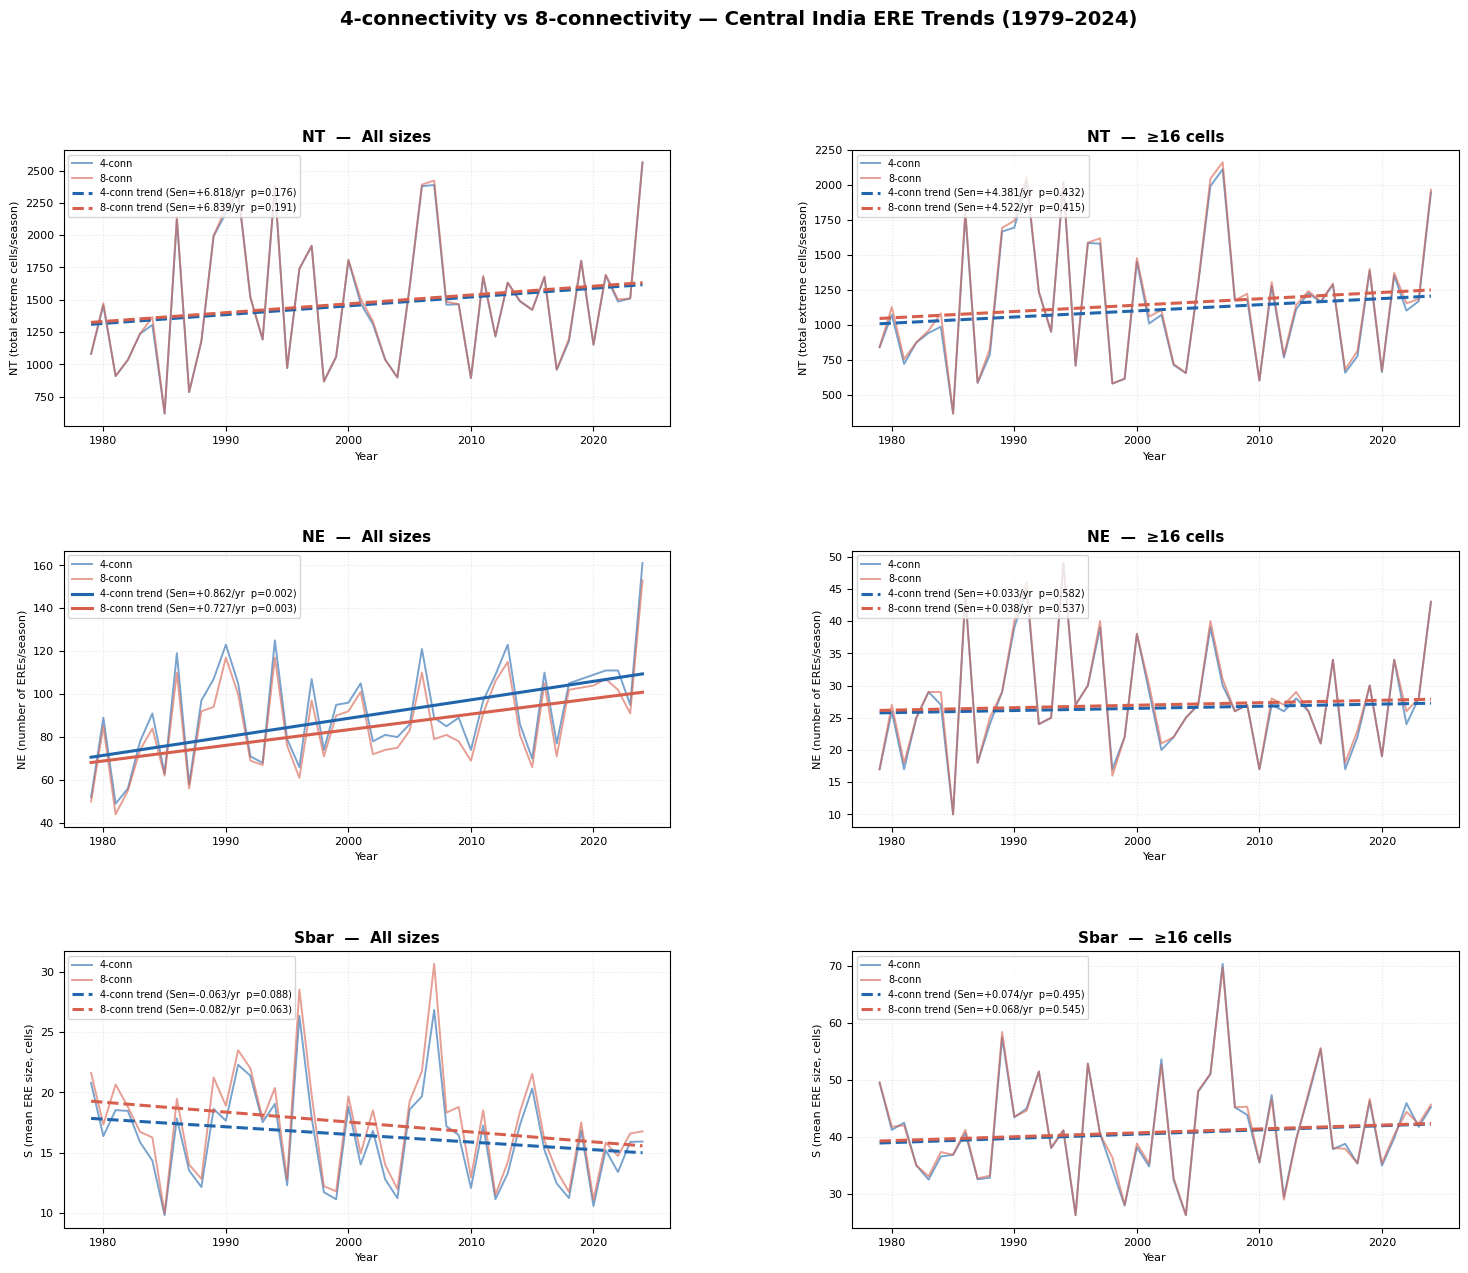

saved → connectivity_comparison.png


In [12]:
# ── Cell 9 : visual comparison — 4-conn vs 8-conn (all sizes + filtered) ──────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

fig = plt.figure(figsize=(18, 14))
fig.suptitle("4-connectivity vs 8-connectivity — Central India ERE Trends (1979–2024)",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)

configs = {
    "All sizes":   (df_4all,  df_8all),
    "≥16 cells":   (df_4filt, df_8filt),
}

variables = ['NT', 'NE', 'Sbar']
ylabels   = ['NT (total extreme cells/season)',
             'NE (number of EREs/season)',
             'S̄ (mean ERE size, cells)']

colors = {'4-conn': '#2166ac', '8-conn': '#d6604d'}

for col_idx, (config_name, (df4, df8)) in enumerate(configs.items()):
    for row_idx, (var, ylabel) in enumerate(zip(variables, ylabels)):

        ax = fig.add_subplot(gs[row_idx, col_idx])

        y4 = df4[var].values
        y8 = df8[var].values
        x  = df4['year'].values

        # raw lines
        ax.plot(x, y4, color=colors['4-conn'], lw=1.4, alpha=0.6, label='4-conn')
        ax.plot(x, y8, color=colors['8-conn'], lw=1.4, alpha=0.6, label='8-conn')

        # Sen's slope trend lines
        for df_in, col, conn_name in [(df4, colors['4-conn'], '4-conn'),
                                       (df8, colors['8-conn'], '8-conn')]:
            s = df_in[var].dropna().values
            mk_res = mk.original_test(s)
            n      = len(s)
            # reconstruct trend line from Sen's slope + median intercept
            trend_line = mk_res.intercept + mk_res.slope * np.arange(n)
            sig_label  = f"{conn_name} trend (Sen={mk_res.slope:+.3f}/yr" \
                         f"{'  p='+f'{mk_res.p:.3f}' if mk_res.p < 0.05 else '  p='+f'{mk_res.p:.3f}'})"
            ls = '-' if mk_res.p < 0.05 else '--'
            ax.plot(x, trend_line, color=col, lw=2.2, ls=ls, label=sig_label)

        ax.set_title(f"{var}  —  {config_name}", fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_xlabel("Year", fontsize=8)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3, linestyle=':')

plt.savefig('connectivity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved → connectivity_comparison.png")

In [13]:
# ── Cell 10 : size distribution histogram — 4-conn vs 8-conn ─────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def get_full_size_distribution(Label_arr, NE_arr, n_days):
    """Returns array of all ERE sizes (in cells) across all days."""
    sizes = []
    for k in range(n_days):
        if NE_arr[k] == 0:
            continue
        labeled = Label_arr[k]
        for lbl in range(1, NE_arr[k] + 1):
            size = int((labeled == lbl).sum())
            sizes.append(size)
    return np.array(sizes)

sizes4 = get_full_size_distribution(Label4, NE4, n_days)
sizes8 = get_full_size_distribution(Label8, NE8, n_days)

# ── bin structure ─────────────────────────────────────────────────────────────
bins = [1,2,3,4,5,6,8,10,13,16,20,25,31,40,51,65,81,91,121,161,999]
bin_labels = ['1','2','3','4','5','6-7','8-9','10-12','13-15',
              '16-19','20-24','25-30','31-39','40-50','51-64',
              '65-80','81-90','91-120','121-160','161+']

def bin_sizes(sizes, bins):
    counts = []
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        n = ((sizes >= lo) & (sizes < hi)).sum()
        counts.append(n)
    return np.array(counts)

counts4 = bin_sizes(sizes4, bins)
counts8 = bin_sizes(sizes8, bins)

pct4 = counts4 / counts4.sum() * 100
pct8 = counts8 / counts8.sum() * 100

# ── print table ───────────────────────────────────────────────────────────────
print(f"\n{'Bin':<12} {'4-conn N':>10} {'4-conn %':>10} {'8-conn N':>10} {'8-conn %':>10} {'diff N':>8}")
print("-" * 55)
for i, bl in enumerate(bin_labels):
    print(f"  {bl:<10} {counts4[i]:>10,} {pct4[i]:>9.2f}% "
          f"{counts8[i]:>10,} {pct8[i]:>9.2f}% "
          f"{counts8[i]-counts4[i]:>+8,}")

print(f"\n  {'TOTAL':<10} {counts4.sum():>10,} {'100.00%':>10} "
      f"{counts8.sum():>10,} {'100.00%':>10}")

# category summary
print(f"\n  Category summary:")
cat_bins = [(0,  16,  'Sub-ref  (<16 cells)'),
            (9,  17,  'Medium   (16-90 cells)'),
            (17, 20,  'Large    (≥91 cells)')]
for lo_i, hi_i, label in cat_bins:
    n4 = counts4[lo_i:hi_i].sum()
    n8 = counts8[lo_i:hi_i].sum()
    print(f"    {label} : 4-conn {n4:>6,} ({n4/counts4.sum()*100:.1f}%)  "
          f"8-conn {n8:>6,} ({n8/counts8.sum()*100:.1f}%)")


Bin            4-conn N   4-conn %   8-conn N   8-conn %   diff N
-------------------------------------------------------
  1               3,888     26.16%      2,904     21.26%     -984
  2               1,976     13.29%      1,879     13.76%      -97
  3               1,304      8.77%      1,268      9.28%      -36
  4               1,050      7.06%      1,029      7.53%      -21
  5                 786      5.29%        757      5.54%      -29
  6-7             1,086      7.31%      1,050      7.69%      -36
  8-9               830      5.58%        808      5.92%      -22
  10-12             854      5.75%        839      6.14%      -15
  13-15             606      4.08%        601      4.40%       -5
  16-19             555      3.73%        562      4.11%       +7
  20-24             463      3.11%        469      3.43%       +6
  25-30             384      2.58%        377      2.76%       -7
  31-39             325      2.19%        336      2.46%      +11
  40-50            

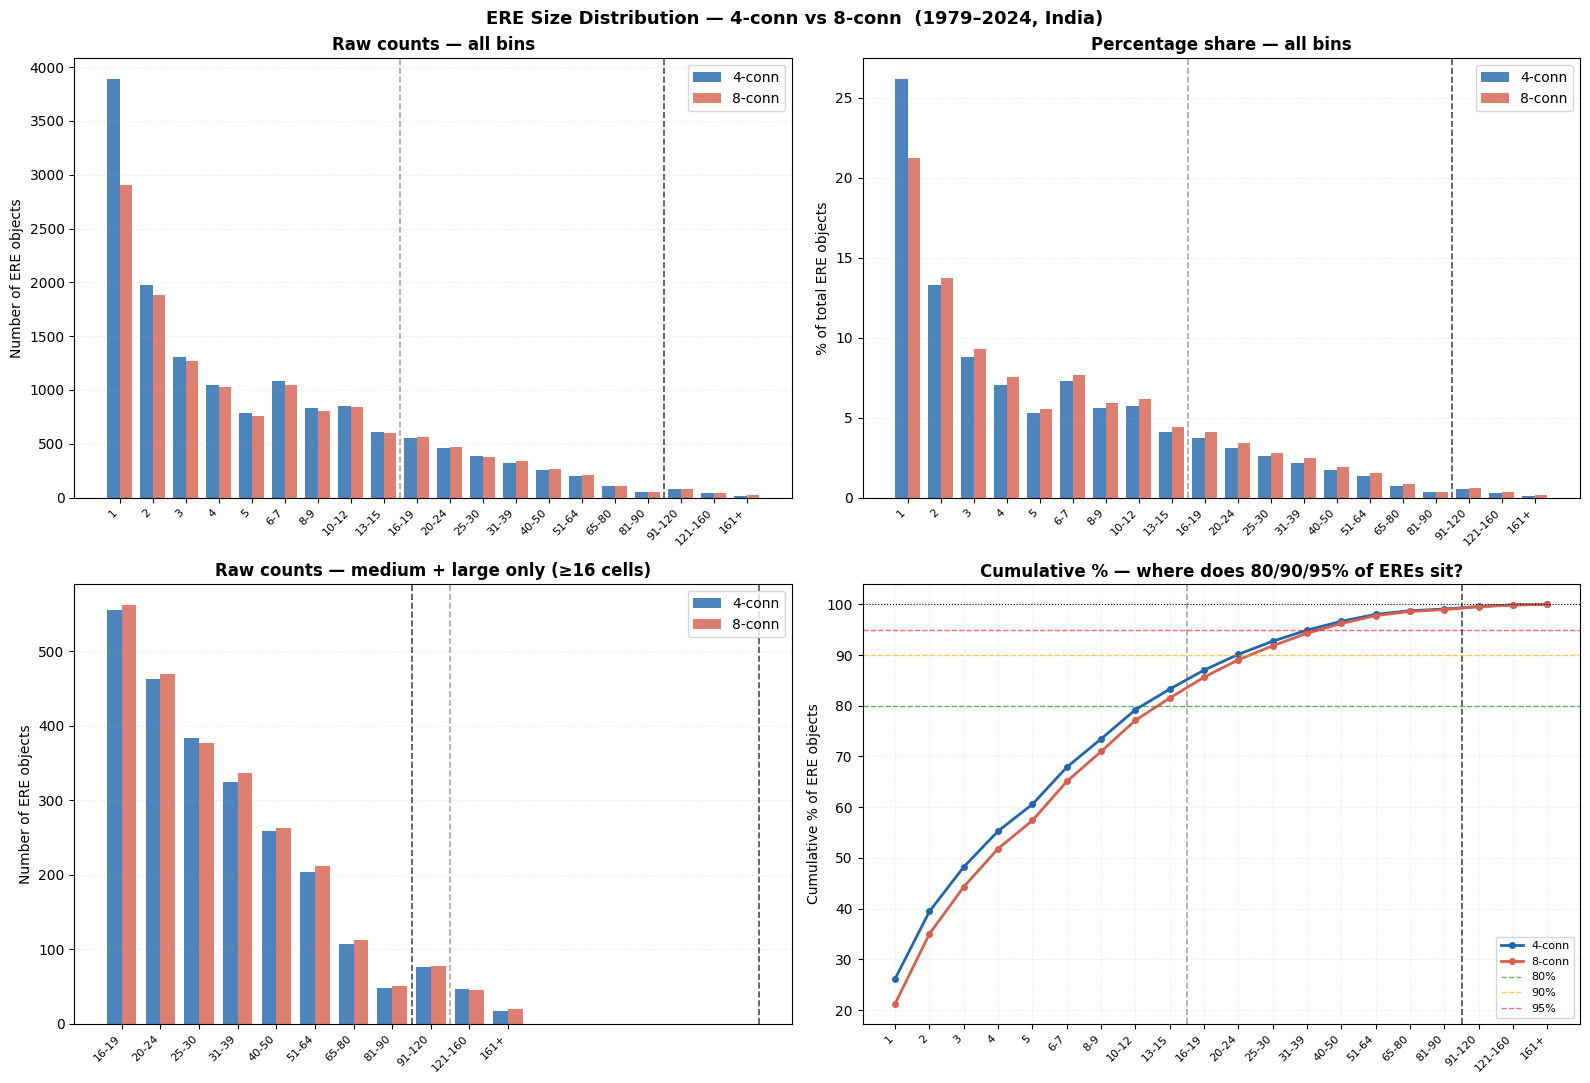

saved → size_distribution_comparison.png


In [14]:
# ── Cell 11 : plots ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("ERE Size Distribution — 4-conn vs 8-conn  (1979–2024, India)",
             fontsize=13, fontweight='bold', y=0.98)

x     = np.arange(len(bin_labels))
width = 0.38

# ── Plot 1 : raw counts, full range ──────────────────────────────────────────
ax = axes[0, 0]
ax.bar(x - width/2, counts4, width, label='4-conn', color='#2166ac', alpha=0.8)
ax.bar(x + width/2, counts8, width, label='8-conn', color='#d6604d', alpha=0.8)
ax.set_title("Raw counts — all bins", fontweight='bold')
ax.set_ylabel("Number of ERE objects")
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle=':')

# vertical lines for size categories
for ax_ in axes.flat:
    ax_.axvline(x=8.5, color='gray',   lw=1.2, ls='--', alpha=0.7)   # <16 / medium boundary
    ax_.axvline(x=16.5, color='black', lw=1.2, ls='--', alpha=0.7)   # medium / large boundary

# ── Plot 2 : percentage, full range ──────────────────────────────────────────
ax = axes[0, 1]
ax.bar(x - width/2, pct4, width, label='4-conn', color='#2166ac', alpha=0.8)
ax.bar(x + width/2, pct8, width, label='8-conn', color='#d6604d', alpha=0.8)
ax.set_title("Percentage share — all bins", fontweight='bold')
ax.set_ylabel("% of total ERE objects")
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle=':')

# ── Plot 3 : zoom in — medium + large only (≥16 cells) ───────────────────────
med_large_idx = list(range(9, len(bin_labels)))   # bins starting at 16-19
ax = axes[1, 0]
x2 = np.arange(len(med_large_idx))
ax.bar(x2 - width/2, counts4[med_large_idx], width, label='4-conn', color='#2166ac', alpha=0.8)
ax.bar(x2 + width/2, counts8[med_large_idx], width, label='8-conn', color='#d6604d', alpha=0.8)
ax.set_title("Raw counts — medium + large only (≥16 cells)", fontweight='bold')
ax.set_ylabel("Number of ERE objects")
ax.set_xticks(x2)
ax.set_xticklabels([bin_labels[i] for i in med_large_idx], rotation=45, ha='right', fontsize=8)
ax.axvline(x=7.5, color='black', lw=1.2, ls='--', alpha=0.7)   # medium / large boundary
ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle=':')

# ── Plot 4 : cumulative % ─────────────────────────────────────────────────────
ax = axes[1, 1]
cum4 = np.cumsum(pct4)
cum8 = np.cumsum(pct8)
ax.plot(x, cum4, color='#2166ac', lw=2, marker='o', ms=4, label='4-conn')
ax.plot(x, cum8, color='#d6604d', lw=2, marker='o', ms=4, label='8-conn')
ax.axhline(y=100, color='k', lw=0.8, ls=':')
ax.set_title("Cumulative % — where does 80/90/95% of EREs sit?", fontweight='bold')
ax.set_ylabel("Cumulative % of ERE objects")
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)

# annotate 80/90/95 thresholds
for thresh, col in [(80,'green'),(90,'orange'),(95,'red')]:
    ax.axhline(y=thresh, color=col, lw=1, ls='--', alpha=0.6, label=f'{thresh}%')
ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('size_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved → size_distribution_comparison.png")

In [18]:
# ── Cell 12 : pre/post-2000 sub-period trend analysis ────────────────────────
# Tests whether S-bar trend is consistent across both sub-periods
# or only appears in one — key check for ERA5 data quality confounding.
# Uses 4-conn / ≥16 cells as canonical config.

periods = {
    'Full  (1979-2024)' : (1979, 2024),
    'Pre-2000 (1979-1999)': (1979, 1999),
    'Post-2000 (2000-2024)': (2000, 2024),
}

print(f"\n{'Period':<25} {'Var':<6} {'MK trend':<14} "
      f"{'MK p':<8} {'Sen slope':>10} {'sig':>5}")
print("=" * 72)

for period_name, (yr_start, yr_end) in periods.items():

    # subset the annual dataframe
    df_sub = df_4filt[
        (df_4filt['year'] >= yr_start) &
        (df_4filt['year'] <= yr_end)
    ].copy()

    n_years = len(df_sub)
    print(f"\n  {period_name}  (n={n_years} years)")
    print(f"  {'-'*68}")

    for var in ['NT', 'NE', 'Sbar']:
        series = df_sub[var].dropna().values

        if len(series) < 8:
            print(f"    {var:<6} — too few years to test")
            continue

        mk_result = mk.original_test(series)
        lr        = stats.linregress(np.arange(len(series)), series)

        sig = '*SIG*' if mk_result.p < 0.05 else ''
        print(f"    {var:<6}  MK: {mk_result.trend:<14} "
              f"p={mk_result.p:.4f}  "
              f"Sen={mk_result.slope:>+8.4f}/yr  "
              f"LR slope={lr.slope:>+8.4f}/yr  {sig}")


Period                    Var    MK trend       MK p      Sen slope   sig

  Full  (1979-2024)  (n=46 years)
  --------------------------------------------------------------------
    NT      MK: no trend       p=0.4319  Sen= +4.3810/yr  LR slope= +3.1311/yr  
    NE      MK: no trend       p=0.5818  Sen= +0.0333/yr  LR slope= +0.0278/yr  
    Sbar    MK: no trend       p=0.4954  Sen= +0.0741/yr  LR slope= +0.0685/yr  

  Pre-2000 (1979-1999)  (n=21 years)
  --------------------------------------------------------------------
    NT      MK: no trend       p=0.6946  Sen=+14.5417/yr  LR slope=+17.3403/yr  
    NE      MK: no trend       p=0.2139  Sen= +0.4143/yr  LR slope= +0.4506/yr  
    Sbar    MK: no trend       p=0.6506  Sen= -0.1823/yr  LR slope= -0.1447/yr  

  Post-2000 (2000-2024)  (n=25 years)
  --------------------------------------------------------------------
    NT      MK: no trend       p=0.7614  Sen= +2.7182/yr  LR slope= +1.0515/yr  
    NE      MK: no trend       p=